In [1]:
!pip install pandas numpy scikit-learn nltk spacy

In [2]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 2.2 MB/s eta 0:00:06
     -- ------------------------------------- 0.8/12.8 MB 1.1 MB/s eta 0:00:12
     -- ------------------------------------- 0.8/12.8 MB 1.1 MB/s eta 0:00:12
     ---- ----------------------------------- 1.6/12.8 MB 1.5 MB/s eta 0:00:08
     ------ --------------------------------- 2.1/12.8 MB 1.7 MB/s eta 0:00:07
     --------- ------------------------------ 2.9/12.8 MB 2.0 MB/s eta 0:00:05
     ------------ --------------------------- 3.9/12.8 MB 2.4 MB/s eta 0:00:04
     --------------- ------------------------ 5.0/12.8 MB 2.7 MB/s eta 0:00:03
     ------------------- -------------------- 6.3/12.8 MB 3.1 MB/s eta 0:00:03
 

In [3]:
import pandas as pd
import numpy as np
import nltk
import re
import spacy

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [5]:
import zipfile

zip_path = r"C:\Users\Keerthana gowda v\Downloads\Resume.csv.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(r"C:\Users\Keerthana gowda v\Downloads")

print("Dataset extracted successfully")

Dataset extracted successfully


In [6]:
import pandas as pd

data = pd.read_csv(r"C:\Users\Keerthana gowda v\Downloads\Resume.csv")

data.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [7]:
data.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

In [8]:
data = data[['Resume_str','Category']]

data.head()

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


In [9]:
import nltk
import re
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

data['clean_resume'] = data['Resume_str'].apply(clean_text)

data.head()

[nltk_data] Downloading package stopwords to C:\Users\Keerthana gowda
[nltk_data]     v\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Resume_str,Category,clean_resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,hr administratormarketing associate hr adminis...
1,"HR SPECIALIST, US HR OPERATIONS ...",HR,hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,HR,hr director summary years experience recruitin...
3,HR SPECIALIST Summary Dedica...,HR,hr specialist summary dedicated driven dynamic...
4,HR MANAGER Skill Highlights ...,HR,hr manager skill highlights hr skills hr depar...


In [10]:
job_description = """
Looking for a Data Scientist skilled in Python, Machine Learning,
Data Analysis, NLP, Pandas, Scikit-learn, and Data Visualization.
"""

In [11]:
job_description = clean_text(job_description)

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

resume_vectors = vectorizer.fit_transform(data['clean_resume'])

job_vector = vectorizer.transform([job_description])

In [13]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_scores = cosine_similarity(resume_vectors, job_vector)

data['similarity_score'] = similarity_scores

In [14]:
ranked_resumes = data.sort_values(by='similarity_score', ascending=False)

ranked_resumes[['similarity_score','Resume_str']].head(10)

,similarity_score,Resume_str
1218,0.395995,Pavithra Shetty Summary ...
1762,0.331800,ENGINEERING AND QUALITY TECHNICIAN ...
1339,0.291422,DATA ANALYST Professional Summa...
926,0.238257,SOFTWARE DEVELOPER Professi...
331,0.215413,MASTER DATA MANAGER Experie...
1303,0.213582,SENIOR DIGITAL MARKETING ANALYST ...
1040,0.195430,SALES COORDINATOR Summary Cu...
929,0.176158,"VP, PRINCIPAL Summary I am ..."
1091,0.175255,SALES ENGINEER Summary I...
2153,0.164558,"CORPORATE BANKING ASSISTANT, INTERN ..."


In [15]:
skills = [
    "python",
    "machine learning",
    "nlp",
    "data analysis",
    "pandas",
    "scikit learn",
    "deep learning",
    "statistics"
]

In [16]:
def extract_skills(text):

    found_skills = []

    for skill in skills:

        if skill in text:

            found_skills.append(skill)

    return found_skills

data['skills'] = data['clean_resume'].apply(extract_skills)

data[['skills']].head()

,skills
0,"[data analysis, statistics]"
1,[]
2,[]
3,[]
4,[]


In [17]:
def missing_skills(resume_skills):

    return list(set(skills) - set(resume_skills))

data['missing_skills'] = data['skills'].apply(missing_skills)

data[['skills','missing_skills']].head()

,skills,missing_skills
0,"[data analysis, statistics]","[machine learning, python, pandas, deep learni..."
1,[],"[statistics, machine learning, python, pandas,..."
2,[],"[statistics, machine learning, python, pandas,..."
3,[],"[statistics, machine learning, python, pandas,..."
4,[],"[statistics, machine learning, python, pandas,..."


In [18]:
ranked_resumes = data.sort_values(by='similarity_score', ascending=False)

ranked_resumes[['similarity_score','skills','missing_skills']].head(10)

,similarity_score,skills,missing_skills
1218,0.395995,"[python, machine learning, data analysis]","[statistics, pandas, deep learning, scikit lea..."
1762,0.331800,"[python, machine learning, data analysis, pand...","[nlp, deep learning, scikit learn]"
1339,0.291422,"[python, data analysis, pandas, scikit learn, ...","[nlp, machine learning, deep learning]"
926,0.238257,"[python, pandas]","[statistics, machine learning, deep learning, ..."
331,0.215413,"[python, data analysis]","[statistics, machine learning, pandas, deep le..."
1303,0.213582,[python],"[statistics, machine learning, pandas, deep le..."
1040,0.195430,"[machine learning, data analysis, statistics]","[python, pandas, deep learning, scikit learn, ..."
929,0.176158,"[python, pandas]","[statistics, machine learning, deep learning, ..."
1091,0.175255,[],"[statistics, machine learning, python, pandas,..."
2153,0.164558,"[python, machine learning]","[statistics, pandas, deep learning, scikit lea..."


In [19]:
top_candidates = ranked_resumes.head(10)

In [21]:
top_candidates = top_candidates.copy()

top_candidates['candidate'] = ["Candidate " + str(i+1) for i in range(len(top_candidates))]

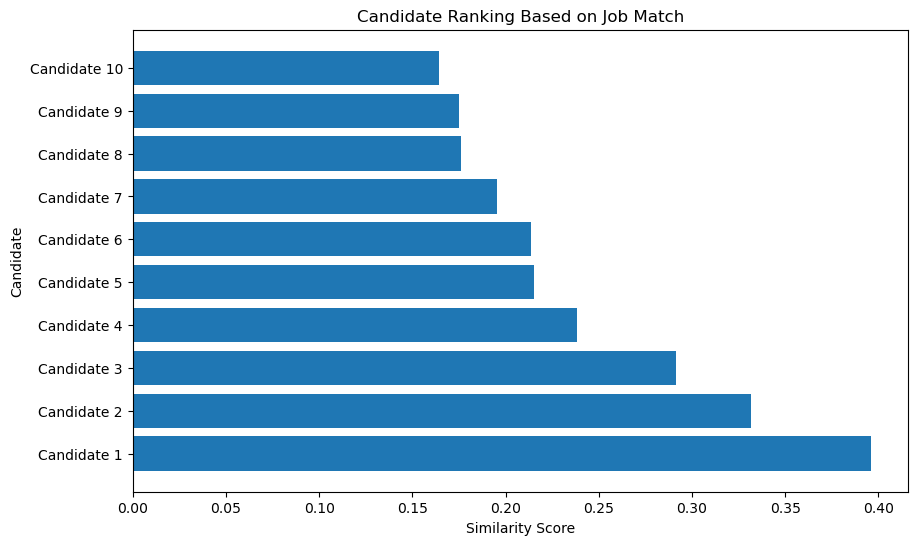

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(top_candidates['candidate'], top_candidates['similarity_score'])

plt.title("Candidate Ranking Based on Job Match")
plt.xlabel("Similarity Score")
plt.ylabel("Candidate")

plt.show()